In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, roc_curve, auc

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)


In [17]:
df = pd.read_csv("wbes_sintetico.csv")
df.head()


,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1


In [18]:
variables = [
    "employees",
    "firm_age_years",
    "training",
    "access_finance",
    "exporter",
    "digital_payments",
    "competition_level",
    "sector",
    "sales_annual_usd",
    "labor_productivity_usd_per_employee",
    "successful"
]

df = df[variables]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   employees                            1190 non-null   float64
 1   firm_age_years                       1174 non-null   float64
 2   training                             1167 non-null   float64
 3   access_finance                       1165 non-null   float64
 4   exporter                             1200 non-null   int64  
 5   digital_payments                     1200 non-null   int64  
 6   competition_level                    1167 non-null   object 
 7   sector                               1187 non-null   object 
 8   sales_annual_usd                     1173 non-null   float64
 9   labor_productivity_usd_per_employee  1200 non-null   float64
 10  successful                           1200 non-null   int64  
dtypes: float64(6), int64(3), objec

In [19]:
print("Nulos por columna:")
display(df.isna().sum())

df = df.dropna().copy()
df.describe(include="all")


Nulos por columna:


employees                              10
firm_age_years                         26
training                               33
access_finance                         35
exporter                                0
digital_payments                        0
competition_level                      33
sector                                 13
sales_annual_usd                       27
labor_productivity_usd_per_employee     0
successful                              0
dtype: int64

,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
count,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000,1035,1035,1035.000000,1035.000000,1035.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,4,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Media,Servicios,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,523,420,NaN,NaN,NaN
mean,12.206763,9.335266,0.421256,0.353623,0.183575,0.583575,NaN,NaN,29803.665875,2978.822092,0.421256
std,8.261429,5.644074,0.493999,0.478325,0.387324,0.493204,NaN,NaN,17316.649436,1895.857080,0.493999
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,4616.266871,504.745429,0.000000
25%,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,17908.343915,1696.484991,0.000000
50%,10.000000,9.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,26037.930090,2560.540352,0.000000
75%,15.000000,13.000000,1.000000,1.000000,0.000000,1.000000,NaN,NaN,37280.646989,3697.058446,1.000000


In [20]:
# REGRESION LINEAL

target_sales = "sales_annual_usd"

features_num = [
    "employees",
    "firm_age_years",
    "training",
    "access_finance",
    "exporter",
    "digital_payments"
]

features_cat = [
    "competition_level",
    "sector"
]

X = df[features_num + features_cat]
y = df[target_sales]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
        ("num", "passthrough", features_num),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [21]:
modelo_lineal = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

modelo_lineal.fit(X_train, y_train)
y_pred = modelo_lineal.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Coeficientes (ya con columnas one-hot)
ohe = modelo_lineal.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(features_cat))
all_feature_names = cat_names + features_num

coefs = modelo_lineal.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": all_feature_names, "coef": coefs}).sort_values("coef", key=lambda s: s.abs(), ascending=False)

display(coef_df.head(15))


R2: 0.4907348834839048
MSE: 190636612.77415285


,feature,coef
10,access_finance,7891.506697
11,exporter,6874.075972
9,training,6115.367183
0,competition_level_Alta,-3781.738852
1,competition_level_Baja,3428.448394
3,sector_Comercio,-2879.520774
4,sector_Manufactura,2232.650907
12,digital_payments,1795.312338
7,employees,1155.966068
6,sector_Tecnologia,976.637096


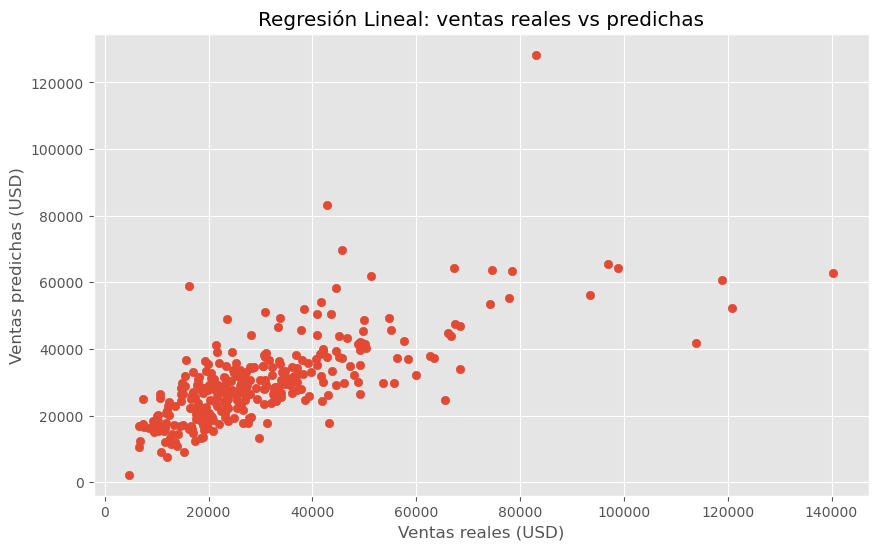

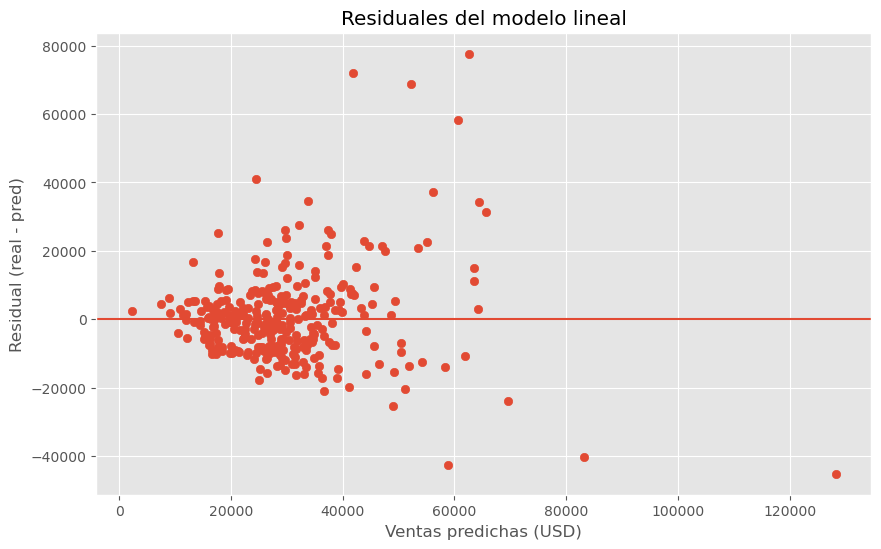

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Ventas reales (USD)")
plt.ylabel("Ventas predichas (USD)")
plt.title("Regresión Lineal: ventas reales vs predichas")
plt.show()

# Residuales
resid = y_test - y_pred
plt.scatter(y_pred, resid)
plt.axhline(0)
plt.xlabel("Ventas predichas (USD)")
plt.ylabel("Residual (real - pred)")
plt.title("Residuales del modelo lineal")
plt.show()


In [23]:
promedio_sales = df["sales_annual_usd"].mean()
df["successful_calc"] = np.where(df["sales_annual_usd"] > promedio_sales, 1, 0)

print("Distribución successful (original):")
display(df["successful"].value_counts())

print("Distribución successful_calc (calculada):")
display(df["successful_calc"].value_counts())


Distribución successful (original):


successful
0    599
1    436
Name: count, dtype: int64

Distribución successful_calc (calculada):


successful_calc
0    622
1    413
Name: count, dtype: int64

In [24]:
# REGRESION LOGISTICA

y_log = df["successful_calc"]

X_log = df[features_num + features_cat]  # mismas variables que usamos en lineal

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.30, random_state=42, stratify=y_log
)


In [25]:
modelo_log = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

modelo_log.fit(X_train, y_train)
y_pred = modelo_log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7845659163987139


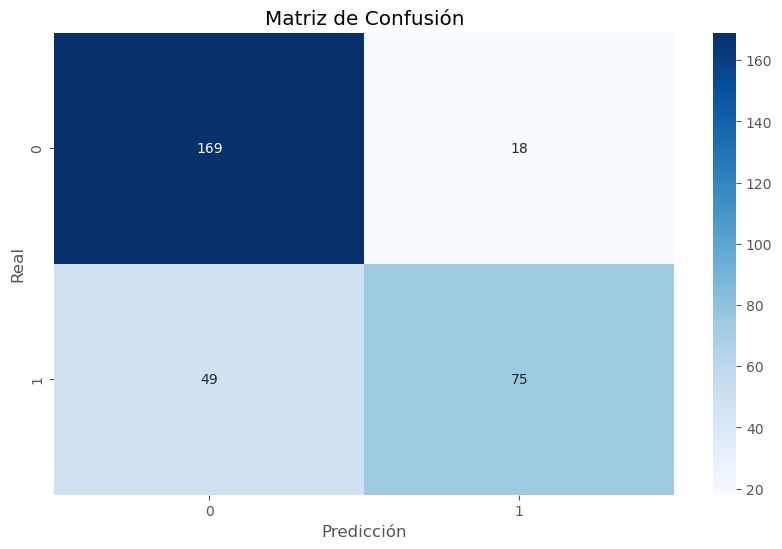

In [26]:
# MATRIZ DE CONFUSION
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


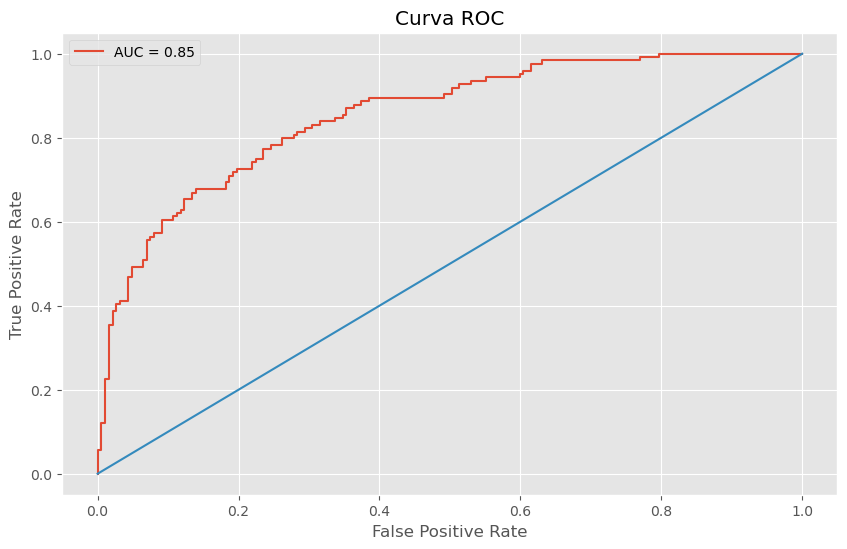

In [27]:
# CURVA ROC
y_prob = modelo_log.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


In [28]:
# REDES BAYESIANAS

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

bayes_vars = ["training", "access_finance", "competition_level", "exporter", "successful_calc"]
df_bayes = df[bayes_vars].copy()

# Estructura causal (hipótesis simple)
model = DiscreteBayesianNetwork([
    ("training", "successful_calc"),
    ("access_finance", "successful_calc"),
    ("competition_level", "successful_calc"),
    ("exporter", "successful_calc")
])

model.fit(df_bayes, estimator=MaximumLikelihoodEstimator)

print("CPDs aprendidas:")
for cpd in model.get_cpds():
    print(cpd)
    print("-"*60)

# Inferencia
infer = VariableElimination(model)

print("\nP(successful=1 | training=1):")
q1 = infer.query(variables=["successful_calc"], evidence={"training": 1})
print(q1)

print("\nP(successful=1 | access_finance=1):")
q2 = infer.query(variables=["successful_calc"], evidence={"access_finance": 1})
print(q2)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'training': 'N', 'access_finance': 'N', 'competition_level': 'C', 'exporter': 'N', 'successful_calc': 'N'}


CPDs aprendidas:
+---------------+----------+
| training(0.0) | 0.578744 |
+---------------+----------+
| training(1.0) | 0.421256 |
+---------------+----------+
------------------------------------------------------------
+--------------------+-----+--------------------------+
| access_finance     | ... | access_finance(1.0)      |
+--------------------+-----+--------------------------+
| competition_level  | ... | competition_level(Media) |
+--------------------+-----+--------------------------+
| exporter           | ... | exporter(1)              |
+--------------------+-----+--------------------------+
| training           | ... | training(1.0)            |
+--------------------+-----+--------------------------+
| successful_calc(0) | ... | 0.35294117647058826      |
+--------------------+-----+--------------------------+
| successful_calc(1) | ... | 0.6470588235294118       |
+--------------------+-----+--------------------------+
-------------------------------------------------

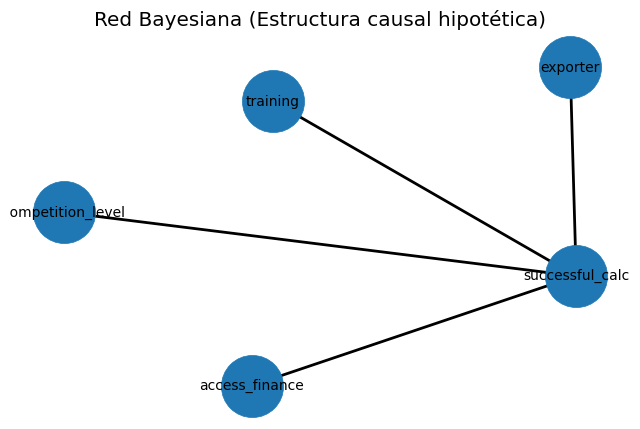

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = nx.spring_layout(G, seed=42)  

nx.draw_networkx_nodes(G, pos, node_size=2000)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=20, width=2)

plt.title("Red Bayesiana (Estructura causal hipotética)")
plt.axis("off")
plt.show()


In [30]:
# INFERENCIA

infer = VariableElimination(model)

# Probabilidad de éxito dado que sí hay capacitación
q1 = infer.query(variables=["successful_calc"], evidence={"training": 1})
print("P(successful | training=1)")
print(q1)

# Probabilidad de éxito dado capacitación y acceso a financiamiento
q2 = infer.query(variables=["successful_calc"], evidence={"training": 1, "access_finance": 1})
print("\nP(successful | training=1, access_finance=1)")
print(q2)


P(successful | training=1)
+--------------------+------------------------+
| successful_calc    |   phi(successful_calc) |
+====================+========================+
| successful_calc(0) |                 0.5114 |
+--------------------+------------------------+
| successful_calc(1) |                 0.4886 |
+--------------------+------------------------+

P(successful | training=1, access_finance=1)
+--------------------+------------------------+
| successful_calc    |   phi(successful_calc) |
+====================+========================+
| successful_calc(0) |                 0.3826 |
+--------------------+------------------------+
| successful_calc(1) |                 0.6174 |
+--------------------+------------------------+
